## In this notebook we will perform Exploratory Data Analysis(EDA)  

In [1]:
import pandas as pd
import numpy as np
import sweetviz as sv #generates beautiful, high-density visualizations
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('../data/enrollment_data.csv')
df.head()

,course_id,tuition_fee,waitlist,retention_rate,feedback_score,faculty_rating,capacity,enrollment
0,162,89376,40,0.53,4.8,2.2,91,167
1,144,75562,10,0.52,2.7,2.2,100,127
2,190,47862,33,0.67,1.1,3.1,101,145
3,149,42159,47,0.84,5.0,4.6,59,185
4,107,35966,49,0.81,3.5,2.6,63,160


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   course_id       5000 non-null   int64  
 1   tuition_fee     5000 non-null   int64  
 2   waitlist        5000 non-null   int64  
 3   retention_rate  5000 non-null   float64
 4   feedback_score  5000 non-null   float64
 5   faculty_rating  5000 non-null   float64
 6   capacity        5000 non-null   int64  
 7   enrollment      5000 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 312.6 KB


In [4]:
df.describe()

,course_id,tuition_fee,waitlist,retention_rate,feedback_score,faculty_rating,capacity,enrollment
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,149.861600,59740.485400,24.897200,0.727090,2.984560,3.492040,75.794400,142.336800
std,29.064132,23006.521388,14.651128,0.129859,1.142864,0.862247,26.297096,25.654922
min,100.000000,20006.000000,0.000000,0.500000,1.000000,2.000000,30.000000,66.000000
25%,125.000000,40002.500000,12.000000,0.620000,2.000000,2.700000,53.000000,124.000000
50%,150.000000,59888.000000,25.000000,0.730000,3.000000,3.500000,76.000000,143.000000
75%,175.000000,79279.750000,37.000000,0.840000,4.000000,4.200000,99.000000,160.000000
max,200.000000,99994.000000,50.000000,0.950000,5.000000,5.000000,120.000000,219.000000


In [5]:
df.isnull().sum()

course_id         0
tuition_fee       0
waitlist          0
retention_rate    0
feedback_score    0
faculty_rating    0
capacity          0
enrollment        0
dtype: int64

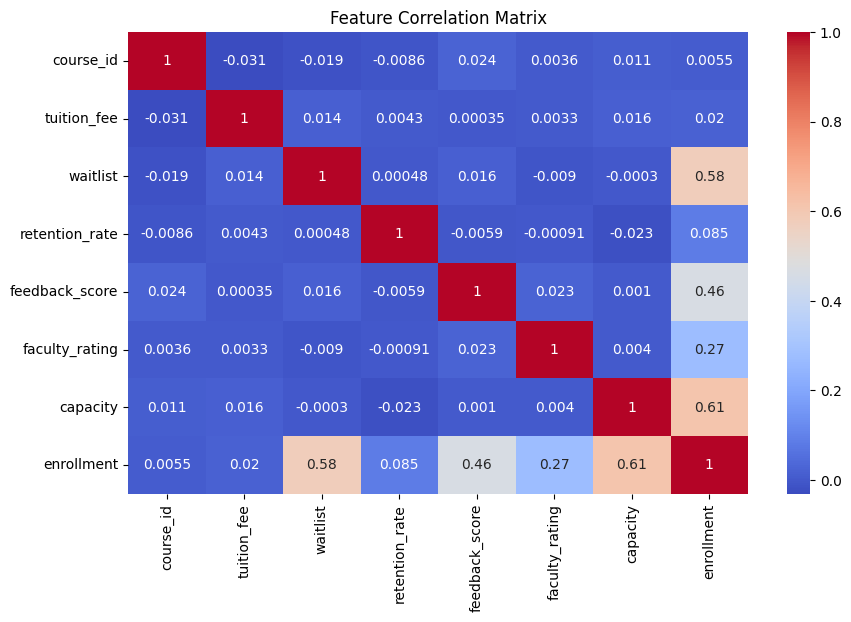

In [6]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

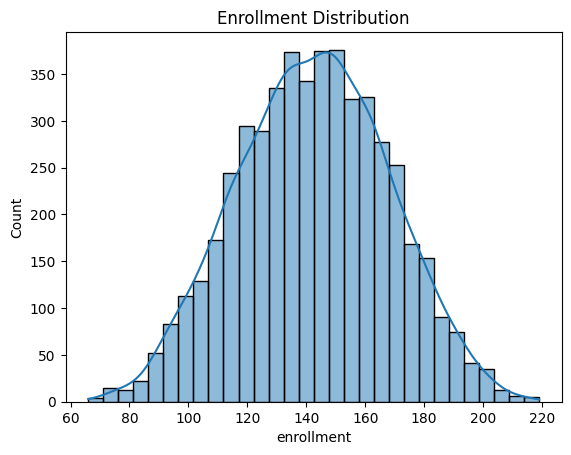

In [7]:
sns.histplot(df["enrollment"], bins=30, kde=True)
plt.title("Enrollment Distribution")
plt.show()

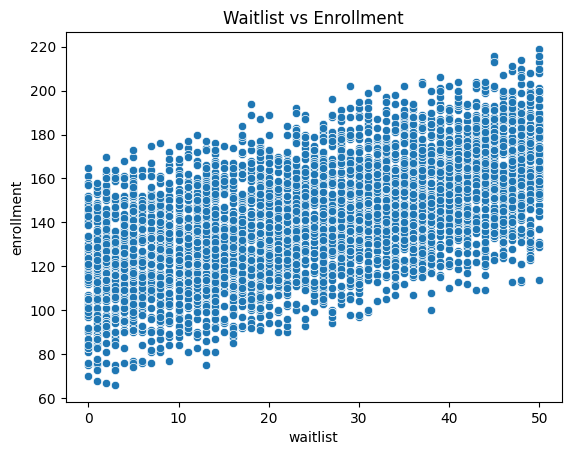

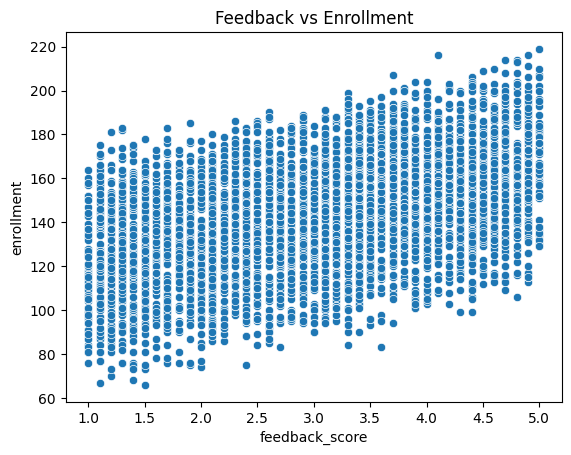

In [8]:
sns.scatterplot(x="waitlist", y="enrollment", data=df)
plt.title("Waitlist vs Enrollment")
plt.show()

sns.scatterplot(x="feedback_score", y="enrollment", data=df)
plt.title("Feedback vs Enrollment")
plt.show()

In [9]:
df["demand_ratio"] = df["waitlist"] / df["capacity"]
df["quality_index"] = df["feedback_score"] * df["faculty_rating"]

df.head()

,course_id,tuition_fee,waitlist,retention_rate,feedback_score,faculty_rating,capacity,enrollment,demand_ratio,quality_index
0,162,89376,40,0.53,4.8,2.2,91,167,0.439560,10.56
1,144,75562,10,0.52,2.7,2.2,100,127,0.100000,5.94
2,190,47862,33,0.67,1.1,3.1,101,145,0.326733,3.41
3,149,42159,47,0.84,5.0,4.6,59,185,0.796610,23.00
4,107,35966,49,0.81,3.5,2.6,63,160,0.777778,9.10


In [10]:
report = sv.analyze(df)
report.show_html("../reports/sweetviz_report.html")

                                             |                                             | [  0%]   00:00 ->…

Report ../reports/sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [11]:
df.corr()["enrollment"].sort_values(ascending=False)

enrollment        1.000000
capacity          0.612163
waitlist          0.576172
quality_index     0.525014
feedback_score    0.462691
faculty_rating    0.274932
demand_ratio      0.131413
retention_rate    0.084500
tuition_fee       0.019959
course_id         0.005483
Name: enrollment, dtype: float64